# ⚡ Element-wise Operations Benchmark: MPS vs CPU

Element-wise tensor operations (`add`, `mul`, `exp`, `sin`, `relu`) are embarrassingly parallel.
On large tensors the GPU can saturate its cores with independent work, minimising the
impact of Metal command-buffer dispatch overhead.

In [ ]:
import torch
from metalcheck import device_info, is_mps_available
from metalcheck.utils import benchmark_elementwise

## 1. Device & System Information

In [2]:
info = device_info()
for k, v in info.items():
    label = k.replace("_", " ").title()
    print(f"{label:<20s}: {v}")

Pytorch Version     : 2.10.0
Python Version      : 3.12.13
Platform            : macOS-26.3.2-arm64-arm-64bit
Architecture        : arm64
Mps Built           : True
Mps Available       : True
Device              : mps


## 2. Element-wise Benchmark

Benchmark five common element-wise ops at increasing tensor sizes (1 M to 100 M elements).

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

ops = ["add", "mul", "exp", "sin", "relu"]
sizes = [1_000_000, 10_000_000, 50_000_000, 100_000_000]
size_labels = ["1M", "10M", "50M", "100M"]
results = []

for op in ops:
    for sz, sz_label in zip(sizes, size_labels):
        for dev_name, dev in [("MPS", torch.device("mps")), ("CPU", torch.device("cpu"))]:
            if dev_name == "MPS" and not is_mps_available():
                continue
            print(f"  {op:>4s} | {sz_label:>4s} | {dev_name} ...", end=" ", flush=True)
            r = benchmark_elementwise(num_elements=sz, op=op, device=dev, iterations=10)
            results.append({
                "Op": op,
                "Elements": sz_label,
                "Device": dev_name,
                "Time (ms)": r["mean_time_s"] * 1000,
            })
            print(f"{r['mean_time_s']*1000:.2f} ms")

df = pd.DataFrame(results)
print("\nElement-wise benchmark complete!")

   add |   1M | MPS ... 0.42 ms
   add |   1M | CPU ... 0.13 ms
   add |  10M | MPS ... 2.75 ms
   add |  10M | CPU ... 2.30 ms
   add |  50M | MPS ... 11.74 ms
   add |  50M | CPU ... 12.20 ms
   add | 100M | MPS ... 28.39 ms
   add | 100M | CPU ... 28.65 ms
   mul |   1M | MPS ... 0.37 ms
   mul |   1M | CPU ... 0.08 ms
   mul |  10M | MPS ... 2.66 ms
   mul |  10M | CPU ... 2.24 ms
   mul |  50M | MPS ... 11.88 ms
   mul |  50M | CPU ... 11.65 ms
   mul | 100M | MPS ... 28.34 ms
   mul | 100M | CPU ... 26.60 ms
   exp |   1M | MPS ... 0.39 ms
   exp |   1M | CPU ... 0.83 ms
   exp |  10M | MPS ... 2.05 ms
   exp |  10M | CPU ... 6.61 ms
   exp |  50M | MPS ... 8.91 ms
   exp |  50M | CPU ... 37.68 ms
   exp | 100M | MPS ... 18.71 ms
   exp | 100M | CPU ... 68.84 ms
   sin |   1M | MPS ... 0.56 ms
   sin |   1M | CPU ... 0.75 ms
   sin |  10M | MPS ... 2.67 ms
   sin |  10M | CPU ... 9.48 ms
   sin |  50M | MPS ... 8.66 ms
   sin |  50M | CPU ... 44.46 ms
   sin | 100M | MPS ... 18.8

## 3. Visualization — Per-operation Charts

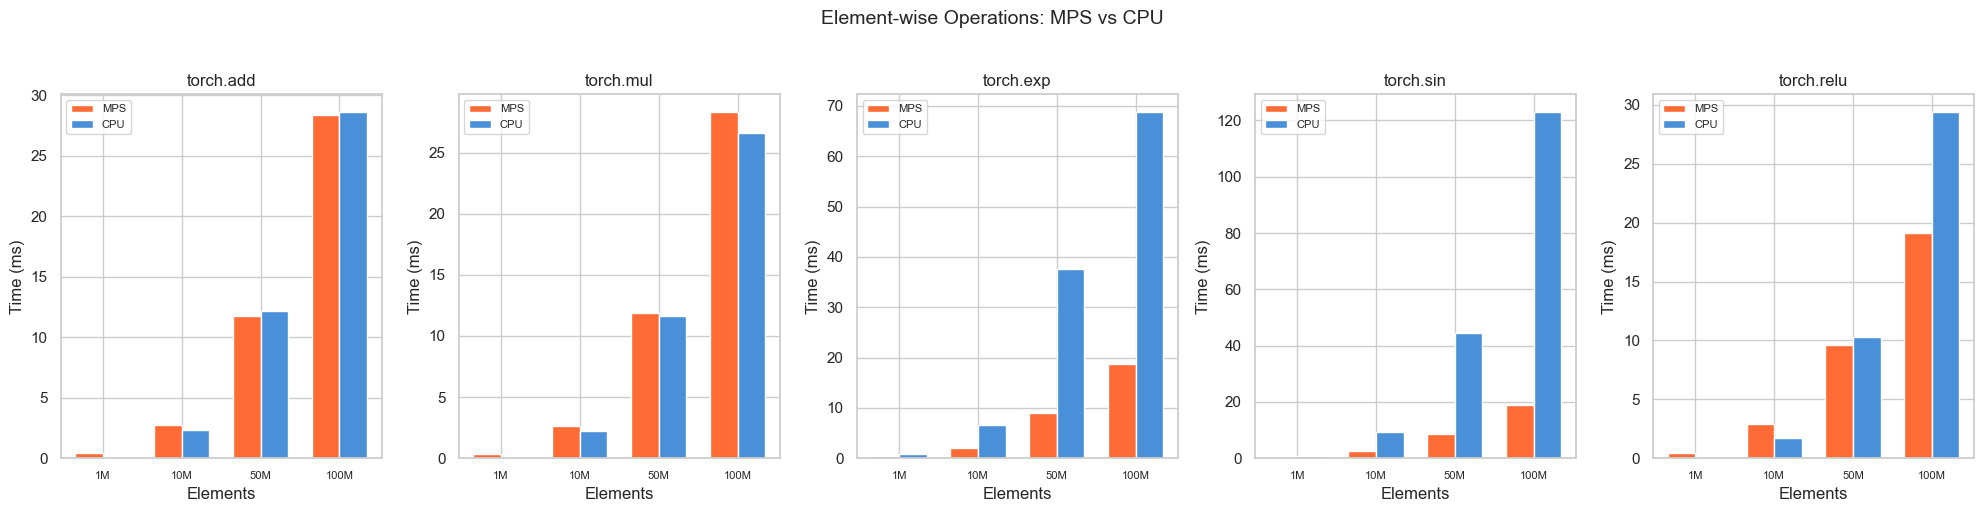

In [4]:
fig, axes = plt.subplots(1, len(ops), figsize=(20, 5), sharey=False)

for ax, op in zip(axes, ops):
    df_op = df[df["Op"] == op]
    x = range(len(sizes))
    width = 0.35

    mps_vals = df_op[df_op["Device"] == "MPS"]["Time (ms)"].tolist()
    cpu_vals = df_op[df_op["Device"] == "CPU"]["Time (ms)"].tolist()

    if mps_vals:
        ax.bar([i - width / 2 for i in x], mps_vals, width, label="MPS", color="#FF6B35")
    ax.bar([i + width / 2 for i in x], cpu_vals, width, label="CPU", color="#4A90D9")

    ax.set_xlabel("Elements")
    ax.set_ylabel("Time (ms)")
    ax.set_title(f"torch.{op}")
    ax.set_xticks(list(x))
    ax.set_xticklabels(size_labels, fontsize=8)
    ax.legend(fontsize=8)

plt.suptitle("Element-wise Operations: MPS vs CPU", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Speedup Heatmap

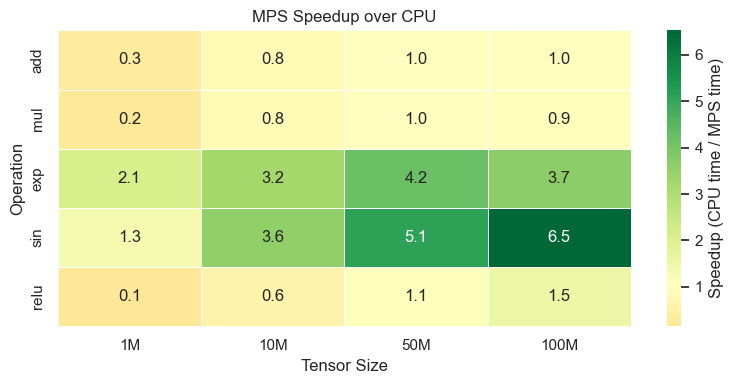

In [5]:
if is_mps_available():
    speedup_data = []
    for op in ops:
        row = {}
        for sz_label in size_labels:
            mps_t = df[(df["Op"] == op) & (df["Elements"] == sz_label) & (df["Device"] == "MPS")]["Time (ms)"].values[0]
            cpu_t = df[(df["Op"] == op) & (df["Elements"] == sz_label) & (df["Device"] == "CPU")]["Time (ms)"].values[0]
            row[sz_label] = cpu_t / mps_t
        speedup_data.append(row)

    df_speedup = pd.DataFrame(speedup_data, index=ops)

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(
        df_speedup, annot=True, fmt=".1f", cmap="RdYlGn",
        center=1.0, linewidths=0.5, ax=ax,
        cbar_kws={"label": "Speedup (CPU time / MPS time)"},
    )
    ax.set_title("MPS Speedup over CPU")
    ax.set_xlabel("Tensor Size")
    ax.set_ylabel("Operation")
    plt.tight_layout()
    plt.show()
else:
    print("MPS not available — cannot compute speedup heatmap.")

## 5. Speedup Summary Table

In [6]:
if is_mps_available():
    rows = []
    for op in ops:
        for sz_label in size_labels:
            mps_t = df[(df["Op"] == op) & (df["Elements"] == sz_label) & (df["Device"] == "MPS")]["Time (ms)"].values[0]
            cpu_t = df[(df["Op"] == op) & (df["Elements"] == sz_label) & (df["Device"] == "CPU")]["Time (ms)"].values[0]
            rows.append({
                "Op": op,
                "Elements": sz_label,
                "MPS (ms)": f"{mps_t:.2f}",
                "CPU (ms)": f"{cpu_t:.2f}",
                "Speedup": f"{cpu_t / mps_t:.1f}x",
            })
    display(pd.DataFrame(rows))
else:
    print("MPS not available — ran CPU only.")

,Op,Elements,MPS (ms),CPU (ms),Speedup
0,add,1M,0.42,0.13,0.3x
1,add,10M,2.75,2.30,0.8x
2,add,50M,11.74,12.20,1.0x
3,add,100M,28.39,28.65,1.0x
4,mul,1M,0.37,0.08,0.2x
5,mul,10M,2.66,2.24,0.8x
6,mul,50M,11.88,11.65,1.0x
7,mul,100M,28.34,26.60,0.9x
8,exp,1M,0.39,0.83,2.1x
9,exp,10M,2.05,6.61,3.2x
